Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
DATASET_DIR: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train
Classes found: ['pigmented benign keratosis', 'melanoma', 'vascular lesion', 'actinic keratosis', 'squamous cell carcinoma', 'basal cell carcinoma', 'seborrheic keratosis', 'dermatofibroma', 'nevus']
Using classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma']


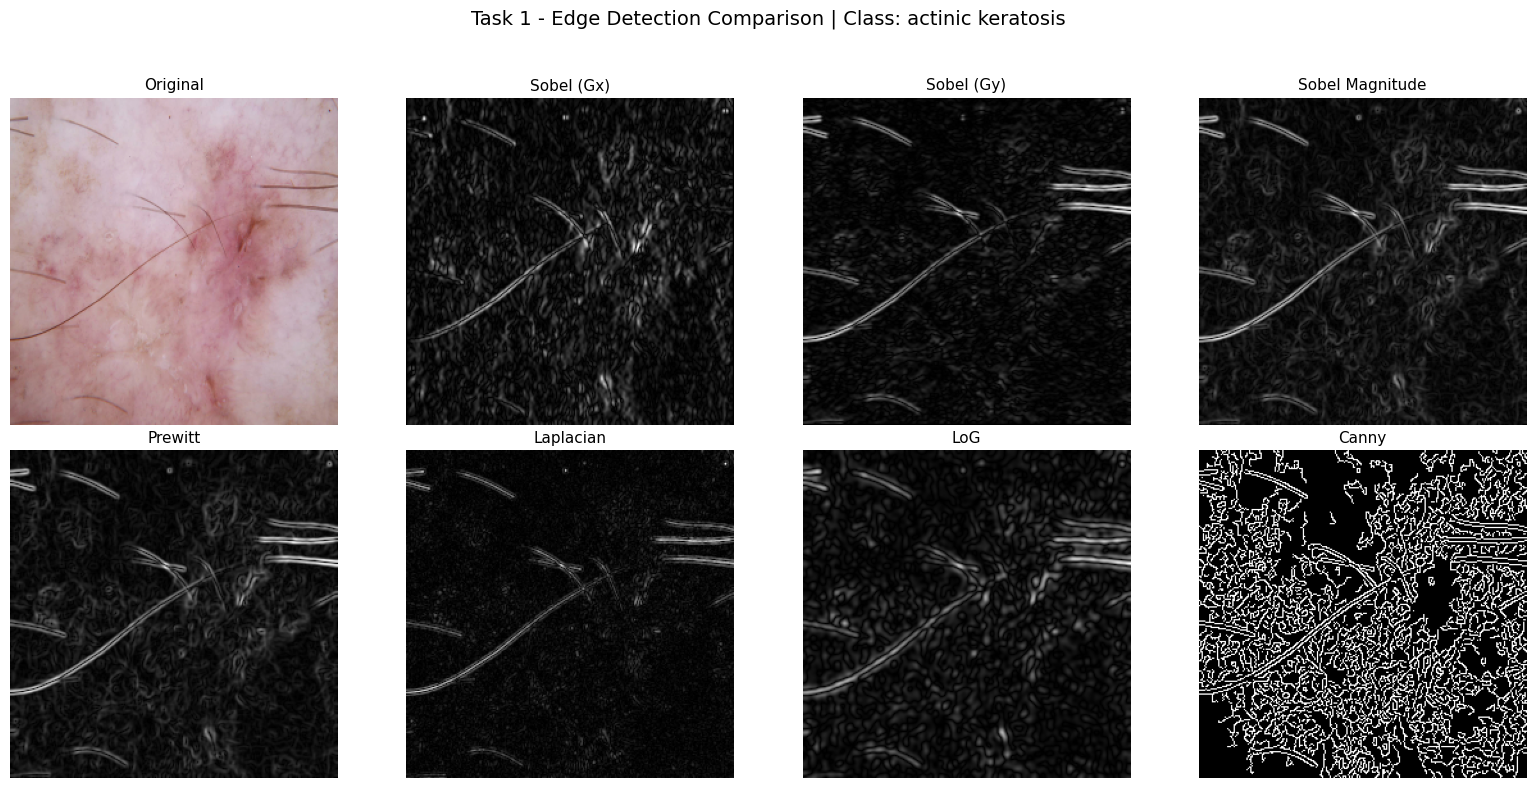

Saved: /content/outputs/task1_actinic_keratosis.png


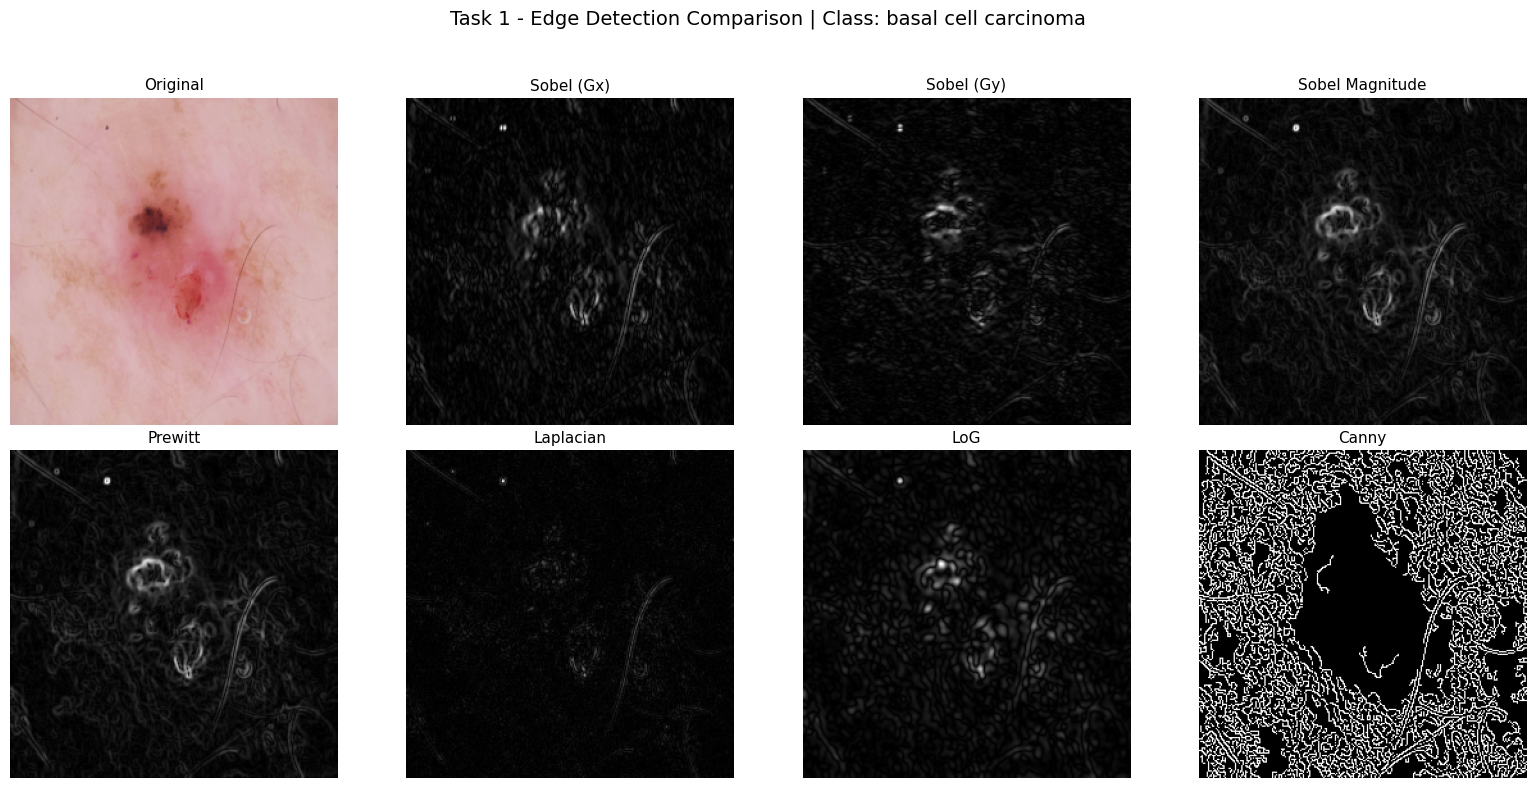

Saved: /content/outputs/task1_basal_cell_carcinoma.png


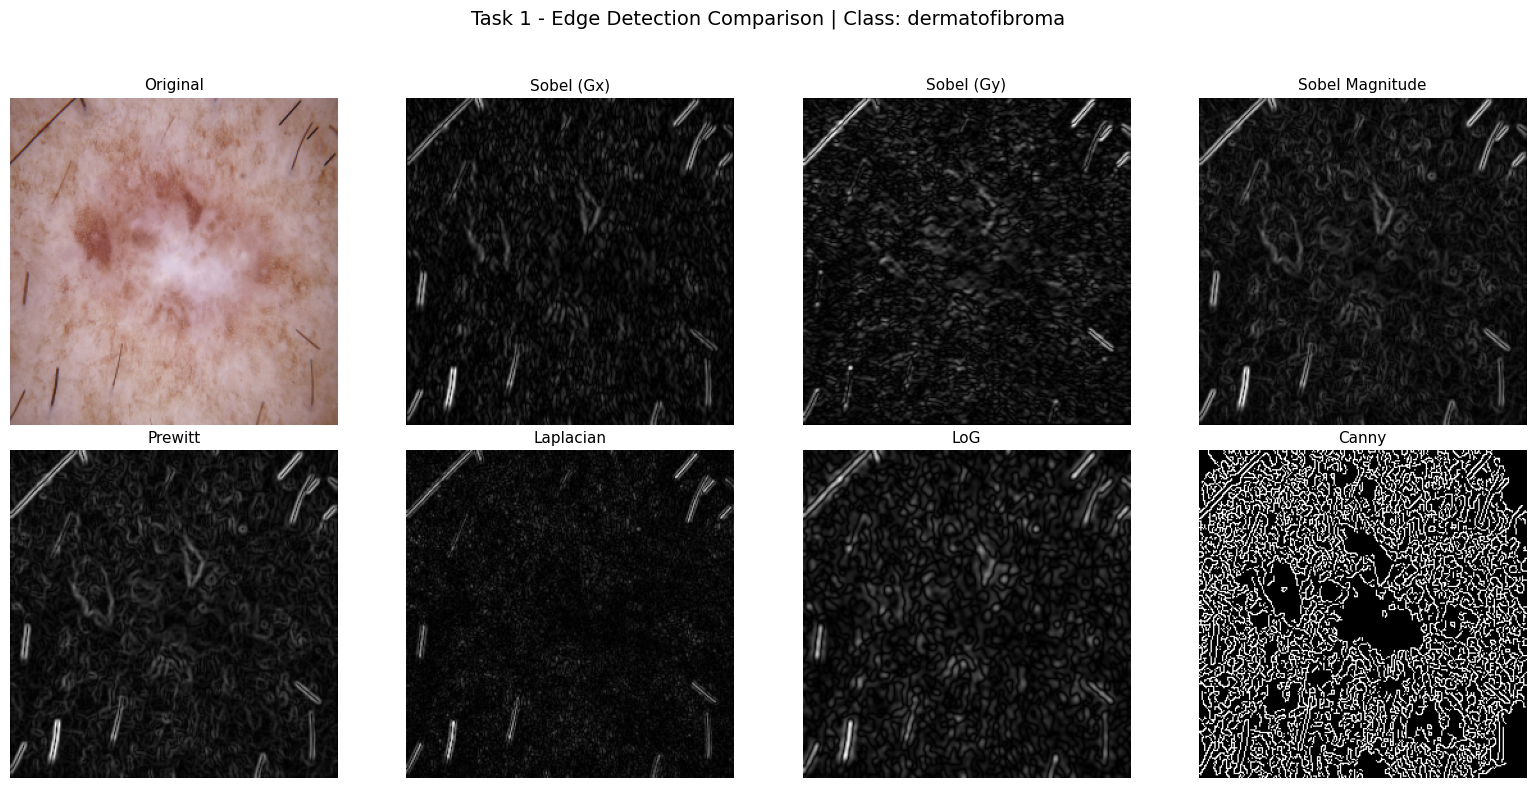

Saved: /content/outputs/task1_dermatofibroma.png


In [ ]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# ---- 1. Install & download dataset ----
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
base = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
DATASET_DIR = os.path.join(base, "Train")
print("DATASET_DIR:", DATASET_DIR)
print("Classes found:", os.listdir(DATASET_DIR))

# ---- 2. Config ----
OUTPUT_DIR = "/content/outputs"
NUM_CLASSES_TO_SAMPLE = 3
IMG_SIZE = (256, 256)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- 3. Helper: pick sample images ----
def get_sample_images(dataset_dir, n_classes=3):
    classes = sorted(d for d in os.listdir(dataset_dir)
                      if os.path.isdir(os.path.join(dataset_dir, d)))
    samples = {}
    for cls in classes[:n_classes]:
        cls_dir = os.path.join(dataset_dir, cls)
        files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
        if files:
            samples[cls] = os.path.join(cls_dir, files[0])
    return samples

# ---- 4. Edge detection functions ----
def apply_sobel(gray):
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.uint8(255*mag/(mag.max()+1e-8))
    return (np.uint8(255*np.abs(sx)/(np.abs(sx).max()+1e-8)),
            np.uint8(255*np.abs(sy)/(np.abs(sy).max()+1e-8)), mag)

def apply_prewitt(gray):
    kx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]], dtype=np.float32)
    ky = np.array([[1,1,1],[0,0,0],[-1,-1,-1]], dtype=np.float32)
    ix = cv2.filter2D(gray.astype(np.float32), -1, kx)
    iy = cv2.filter2D(gray.astype(np.float32), -1, ky)
    mag = np.sqrt(ix**2 + iy**2)
    return np.uint8(255*mag/(mag.max()+1e-8))

def apply_laplacian(gray):
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
    return np.uint8(255*np.abs(lap)/(np.abs(lap).max()+1e-8))

def apply_log(gray, sigma=2.0):
    blurred = ndimage.gaussian_filter(gray.astype(np.float32), sigma=sigma)
    log = ndimage.laplace(blurred)
    return np.uint8(255*np.abs(log)/(np.abs(log).max()+1e-8))

def apply_canny(gray, low=30, high=90):
    # Equalize contrast first - dermoscopy images are low-contrast,
    # so raw thresholds (100/200) give an all-black edge map otherwise.
    gray_eq = cv2.equalizeHist(gray)
    return cv2.Canny(gray_eq, low, high)

# ---- 5. Build the required figure per class ----
def process_and_plot(cls_name, img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    sx, sy, smag = apply_sobel(gray)
    prewitt = apply_prewitt(gray)
    laplacian = apply_laplacian(gray)
    log_img = apply_log(gray)
    canny = apply_canny(gray)

    titles = ["Original", "Sobel (Gx)", "Sobel (Gy)", "Sobel Magnitude",
              "Prewitt", "Laplacian", "LoG", "Canny"]
    images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), sx, sy, smag,
              prewitt, laplacian, log_img, canny]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f"Task 1 - Edge Detection Comparison | Class: {cls_name}", fontsize=14)
    for ax, title, im in zip(axes.ravel(), titles, images):
        cmap = None if title == "Original" else "gray"
        ax.imshow(im, cmap=cmap)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    out_path = os.path.join(OUTPUT_DIR, f"task1_{cls_name.replace(' ', '_')}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

# ---- 6. Run ----
samples = get_sample_images(DATASET_DIR, NUM_CLASSES_TO_SAMPLE)
print("Using classes:", list(samples.keys()))
for cls_name, img_path in samples.items():
    process_and_plot(cls_name, img_path)

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Using image: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis/ISIC_0027580.jpg

=== Table 1: Effect of Noise and Preprocessing on Edge Detection ===
Edge Detector Input Image    Noise Type      Preprocessing  Edge Density (%) Edge Quality Noise Sensitivity
        Sobel    Original          None               None             11.91         High          baseline
        Sobel       Noisy      Gaussian               None             80.17         High  +573.1% vs clean
        Sobel       Noisy Salt & Pepper               None             17.38         High   +45.9% vs clean
        Sobel       Noisy      Gaussian    Gaussian Filter             73.57         High  +517.7% vs clean
        Sobel       Noisy Salt & Pepper      Median Filter              9.31       Medium   -21.8% vs clean
      Prewitt    Original          None         

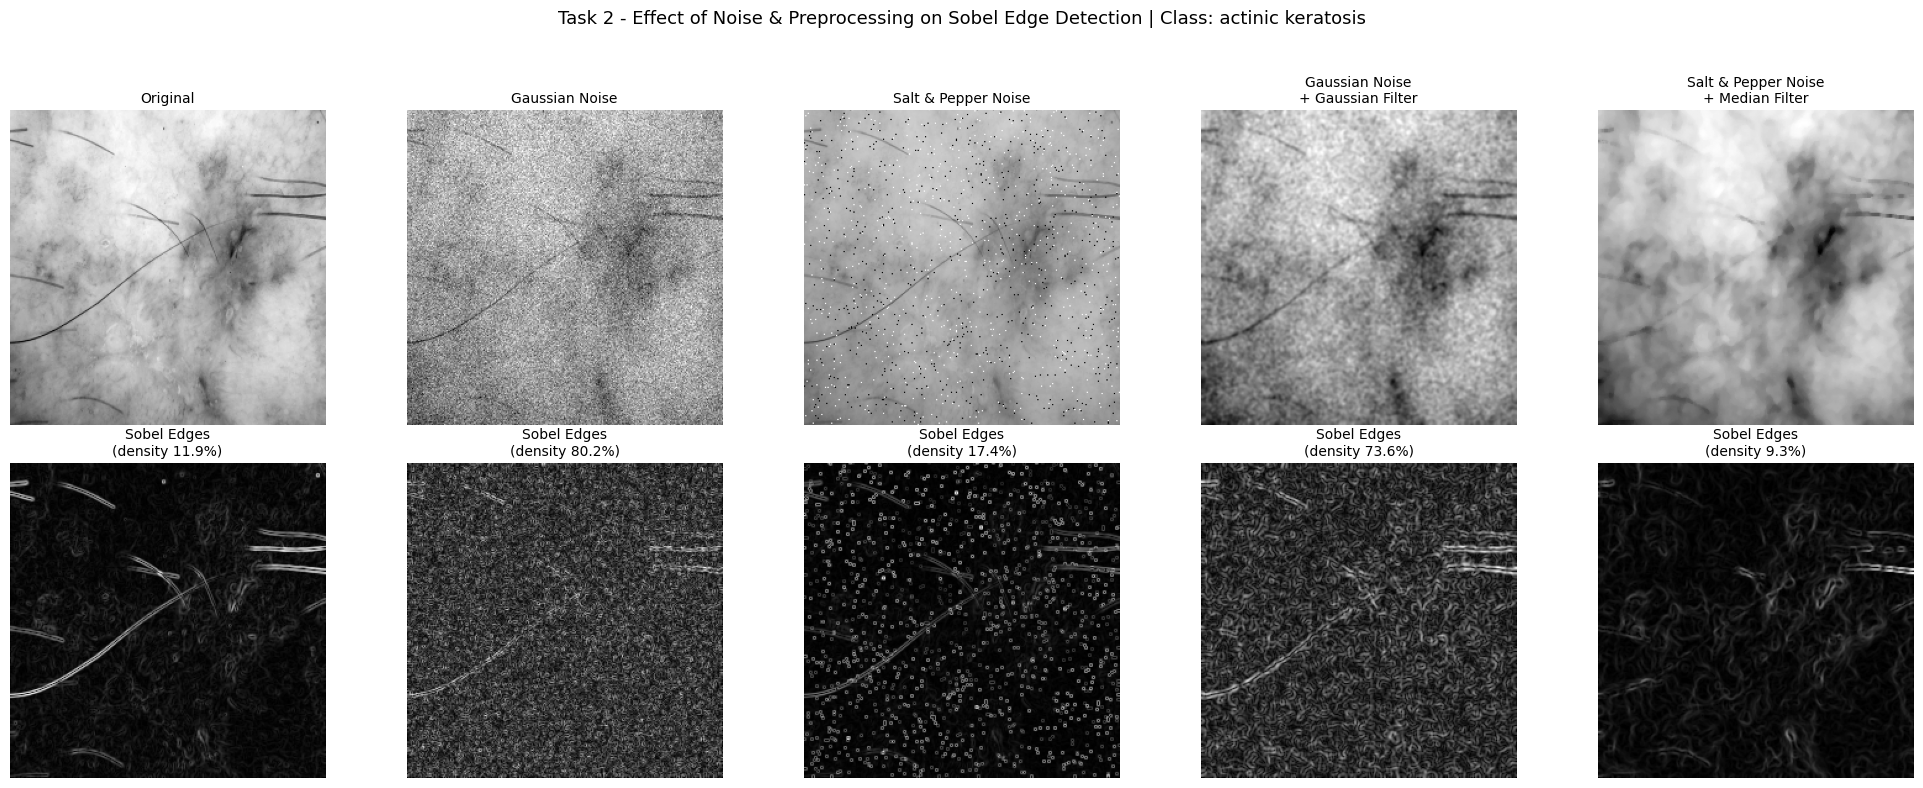

Saved: /content/outputs/task2_noise_effect_sobel.png


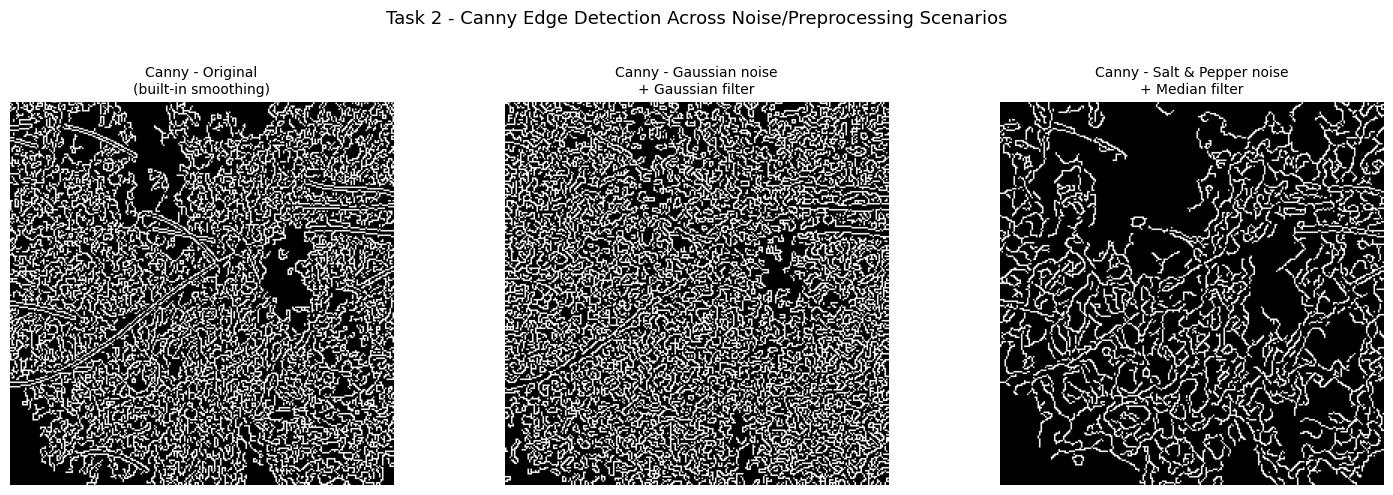

Saved: /content/outputs/task2_noise_effect_canny.png


In [ ]:
import os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

# =====================================================================
# Lab 03 - Task 2: Effect of Noise on Edge Detection
# Self-contained Colab cell: downloads dataset, adds noise, filters,
# runs edge detectors, builds the comparison figure AND Table 1.
# =====================================================================

# ---- 1. Dataset (re-download in case runtime was reset) ----
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
base = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
DATASET_DIR = os.path.join(base, "Train")

OUTPUT_DIR = "/content/outputs"
IMG_SIZE = (256, 256)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# pick one representative image (first class, first image)
first_class = sorted(os.listdir(DATASET_DIR))[0]
cls_dir = os.path.join(DATASET_DIR, first_class)
img_file = [f for f in os.listdir(cls_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))][0]
img_path = os.path.join(cls_dir, img_file)
print("Using image:", img_path)

img = cv2.imread(img_path)
img = cv2.resize(img, IMG_SIZE)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---- 2. Noise functions ----
def add_gaussian_noise(image, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, amount=0.02, salt_vs_pepper=0.5):
    noisy = image.copy()
    num_salt = int(np.ceil(amount * image.size * salt_vs_pepper))
    num_pepper = int(np.ceil(amount * image.size * (1.0 - salt_vs_pepper)))

    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

# ---- 3. Denoising filters ----
def gaussian_denoise(image, ksize=5):
    return cv2.GaussianBlur(image, (ksize, ksize), 0)

def median_denoise(image, ksize=5):
    return cv2.medianBlur(image, ksize)

# ---- 4. Edge detectors (same as Task 1) ----
def apply_sobel(g):
    sx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    return np.uint8(255*mag/(mag.max()+1e-8))

def apply_prewitt(g):
    kx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]], dtype=np.float32)
    ky = np.array([[1,1,1],[0,0,0],[-1,-1,-1]], dtype=np.float32)
    ix = cv2.filter2D(g.astype(np.float32), -1, kx)
    iy = cv2.filter2D(g.astype(np.float32), -1, ky)
    mag = np.sqrt(ix**2 + iy**2)
    return np.uint8(255*mag/(mag.max()+1e-8))

def apply_laplacian(g):
    lap = cv2.Laplacian(g, cv2.CV_64F, ksize=3)
    return np.uint8(255*np.abs(lap)/(np.abs(lap).max()+1e-8))

def apply_log(g, sigma=2.0):
    blurred = ndimage.gaussian_filter(g.astype(np.float32), sigma=sigma)
    log = ndimage.laplace(blurred)
    return np.uint8(255*np.abs(log)/(np.abs(log).max()+1e-8))

def apply_canny(g, low=30, high=90):
    g_eq = cv2.equalizeHist(g)
    return cv2.Canny(g_eq, low, high)

# ---- 5. Build all noisy / filtered versions ----
clean          = gray
noisy_gauss    = add_gaussian_noise(gray)
noisy_sp       = add_salt_pepper_noise(gray)
gauss_filtered = gaussian_denoise(noisy_gauss)   # Gaussian noise -> Gaussian filter
sp_filtered    = median_denoise(noisy_sp)        # Salt&Pepper noise -> Median filter

# ---- 6. Edge quality metric: % of pixels marked as edges ----
def edge_density(edge_img, thresh=30):
    return 100.0 * np.sum(edge_img > thresh) / edge_img.size

def quality_label(density):
    if density < 3:
        return "Low"
    elif density < 10:
        return "Medium"
    else:
        return "High"

# ---- 7. Compute Table 1 rows exactly as specified in the lab handout ----
rows = []

def add_row(detector, input_label, noise_type, preprocessing, edge_img, baseline_density=None):
    density = edge_density(edge_img)
    quality = quality_label(density)
    if baseline_density is not None and baseline_density > 0:
        sensitivity_pct = 100.0 * (density - baseline_density) / baseline_density
        sensitivity = f"{sensitivity_pct:+.1f}% vs clean"
    else:
        sensitivity = "baseline"
    rows.append({
        "Edge Detector": detector,
        "Input Image": input_label,
        "Noise Type": noise_type,
        "Preprocessing": preprocessing,
        "Edge Density (%)": round(density, 2),
        "Edge Quality": quality,
        "Noise Sensitivity": sensitivity,
    })

# --- Sobel rows ---
sobel_clean   = apply_sobel(clean)
sobel_ng      = apply_sobel(noisy_gauss)
sobel_nsp     = apply_sobel(noisy_sp)
sobel_ng_f    = apply_sobel(gauss_filtered)
sobel_nsp_f   = apply_sobel(sp_filtered)
base_d = edge_density(sobel_clean)
add_row("Sobel", "Original", "None", "None", sobel_clean, None)
add_row("Sobel", "Noisy", "Gaussian", "None", sobel_ng, base_d)
add_row("Sobel", "Noisy", "Salt & Pepper", "None", sobel_nsp, base_d)
add_row("Sobel", "Noisy", "Gaussian", "Gaussian Filter", sobel_ng_f, base_d)
add_row("Sobel", "Noisy", "Salt & Pepper", "Median Filter", sobel_nsp_f, base_d)

# --- Prewitt (Original only, per table) ---
prewitt_clean = apply_prewitt(clean)
add_row("Prewitt", "Original", "None", "None", prewitt_clean, None)

# --- Laplacian (Original only, per table) ---
laplacian_clean = apply_laplacian(clean)
add_row("Laplacian", "Original", "None", "None", laplacian_clean, None)

# --- LoG (Noisy+Gaussian filter, per table) ---
log_ng_f = apply_log(gauss_filtered)
add_row("LoG", "Noisy", "Gaussian", "Gaussian Filter", log_ng_f, None)

# --- Canny rows ---
canny_clean = apply_canny(clean)
canny_ng_f  = apply_canny(gauss_filtered)
canny_nsp_f = apply_canny(sp_filtered)
base_c = edge_density(canny_clean)
add_row("Canny", "Original", "None", "Built-in smoothing", canny_clean, None)
add_row("Canny", "Noisy", "Gaussian", "Gaussian Filter", canny_ng_f, base_c)
add_row("Canny", "Noisy", "Salt & Pepper", "Median Filter", canny_nsp_f, base_c)

table1 = pd.DataFrame(rows)
print("\n=== Table 1: Effect of Noise and Preprocessing on Edge Detection ===")
print(table1.to_string(index=False))
table1.to_csv(os.path.join(OUTPUT_DIR, "table1_noise_effect.csv"), index=False)
print(f"\nSaved: {OUTPUT_DIR}/table1_noise_effect.csv")

# ---- 8. Visual comparison figure (Sobel across all scenarios - most complete row) ----
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
top_titles = ["Original", "Gaussian Noise", "Salt & Pepper Noise",
              "Gaussian Noise\n+ Gaussian Filter", "Salt & Pepper Noise\n+ Median Filter"]
top_images = [clean, noisy_gauss, noisy_sp, gauss_filtered, sp_filtered]
bottom_images = [sobel_clean, sobel_ng, sobel_nsp, sobel_ng_f, sobel_nsp_f]

for i in range(5):
    axes[0, i].imshow(top_images[i], cmap="gray")
    axes[0, i].set_title(top_titles[i], fontsize=10)
    axes[0, i].axis("off")
    axes[1, i].imshow(bottom_images[i], cmap="gray")
    axes[1, i].set_title(f"Sobel Edges\n(density {edge_density(bottom_images[i]):.1f}%)", fontsize=10)
    axes[1, i].axis("off")

fig.suptitle(f"Task 2 - Effect of Noise & Preprocessing on Sobel Edge Detection | Class: {first_class}",
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
out_fig = os.path.join(OUTPUT_DIR, "task2_noise_effect_sobel.png")
plt.savefig(out_fig, dpi=150)
plt.show()
print(f"Saved: {out_fig}")

# ---- 9. Extra comparison figure for Canny (built-in smoothing already handles noise differently) ----
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
canny_imgs = [canny_clean, canny_ng_f, canny_nsp_f]
canny_titles = ["Canny - Original\n(built-in smoothing)",
                "Canny - Gaussian noise\n+ Gaussian filter",
                "Canny - Salt & Pepper noise\n+ Median filter"]
for i in range(3):
    axes2[i].imshow(canny_imgs[i], cmap="gray")
    axes2[i].set_title(canny_titles[i], fontsize=10)
    axes2[i].axis("off")
fig2.suptitle("Task 2 - Canny Edge Detection Across Noise/Preprocessing Scenarios", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.92])
out_fig2 = os.path.join(OUTPUT_DIR, "task2_noise_effect_canny.png")
plt.savefig(out_fig2, dpi=150)
plt.show()
print(f"Saved: {out_fig2}")

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Using image: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis/ISIC_0027580.jpg

=== Table 2: Canny Parameter Analysis ===
Configuration  Low Threshold  High Threshold Kernel Size          Edge Quality  Number of Detected Edges (px)                                                            Observation
      Canny-1             30             100         3x3 Over-detected (noisy)                          14534         Thresholds too loose - texture/noise picked up as false edges.
      Canny-2             50             150         3x3 Over-detected (noisy)                          10952         Thresholds too loose - texture/noise picked up as false edges.
      Canny-3            100             200         3x3        Slightly noisy                           5272 Reasonable balance between detecting real edges and suppressing noise.

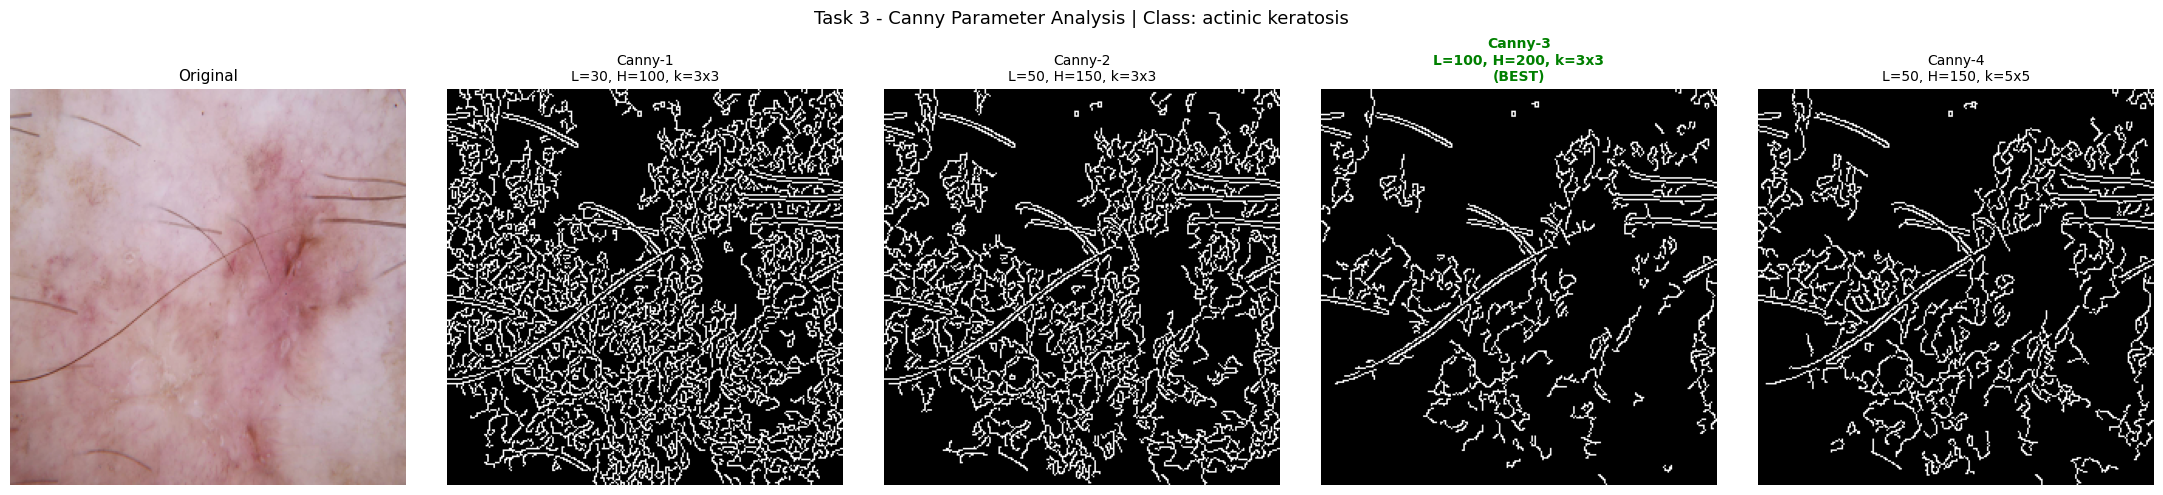

Saved: /content/outputs/task3_canny_param_analysis.png


In [5]:
import os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# Lab 03 - Task 3: Parameter Analysis of Canny Edge Detection
# Self-contained Colab cell: downloads dataset, tests threshold and
# kernel-size combinations, builds Table 2, and picks the best config.
# =====================================================================

# ---- 1. Dataset (re-download in case runtime was reset) ----
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
base = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
DATASET_DIR = os.path.join(base, "Train")

OUTPUT_DIR = "/content/outputs"
IMG_SIZE = (256, 256)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# use the same representative image as Task 1 / Task 2 for consistency
first_class = sorted(os.listdir(DATASET_DIR))[0]
cls_dir = os.path.join(DATASET_DIR, first_class)
img_file = [f for f in os.listdir(cls_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))][0]
img_path = os.path.join(cls_dir, img_file)
print("Using image:", img_path)

img = cv2.imread(img_path)
img = cv2.resize(img, IMG_SIZE)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_eq = cv2.equalizeHist(gray)   # same contrast fix used in Task 1/2

# ---- 2. Canny with configurable threshold + Gaussian kernel size ----
def canny_with_config(gray_img, low, high, ksize):
    """
    ksize = Gaussian smoothing kernel applied BEFORE Canny
    (Canny itself always uses a fixed 3x3 Sobel internally; varying the
    pre-smoothing kernel is the standard way to study 'kernel size' effect
    on Canny's sensitivity to fine detail / noise).
    """
    blurred = cv2.GaussianBlur(gray_img, (ksize, ksize), 0)
    return cv2.Canny(blurred, low, high)

def edge_pixel_count(edge_img):
    return int(np.sum(edge_img > 0))

def edge_density(edge_img):
    return 100.0 * np.sum(edge_img > 0) / edge_img.size

def quality_label(density):
    # heuristic bands for a dermoscopy lesion image (empirically tuned)
    if density < 2:
        return "Low (under-detected)"
    elif density < 6:
        return "Good"
    elif density < 12:
        return "Slightly noisy"
    else:
        return "Over-detected (noisy)"

# ---- 3. Define the required configurations ----
configs = [
    {"name": "Canny-1", "low": 30,  "high": 100, "ksize": 3},
    {"name": "Canny-2", "low": 50,  "high": 150, "ksize": 3},
    {"name": "Canny-3", "low": 100, "high": 200, "ksize": 3},
    {"name": "Canny-4", "low": 50,  "high": 150, "ksize": 5},  # kernel-size variant
]

rows = []
results = {}
for cfg in configs:
    edges = canny_with_config(gray_eq, cfg["low"], cfg["high"], cfg["ksize"])
    results[cfg["name"]] = edges
    density = edge_density(edges)
    count = edge_pixel_count(edges)
    quality = quality_label(density)

    if density < 2:
        obs = "Thresholds too strict for this image - real lesion boundaries missed."
    elif density > 12:
        obs = "Thresholds too loose - texture/noise picked up as false edges."
    else:
        obs = "Reasonable balance between detecting real edges and suppressing noise."

    rows.append({
        "Configuration": cfg["name"],
        "Low Threshold": cfg["low"],
        "High Threshold": cfg["high"],
        "Kernel Size": f'{cfg["ksize"]}x{cfg["ksize"]}',
        "Edge Quality": quality,
        "Number of Detected Edges (px)": count,
        "Observation": obs,
    })

table2 = pd.DataFrame(rows)
print("\n=== Table 2: Canny Parameter Analysis ===")
print(table2.to_string(index=False))
table2.to_csv(os.path.join(OUTPUT_DIR, "table2_canny_params.csv"), index=False)
print(f"\nSaved: {OUTPUT_DIR}/table2_canny_params.csv")

# ---- 4. Pick the best configuration ----
# "Best" = closest edge density to the sweet spot (here: 4-6%), which
# balances catching real lesion-boundary edges without noise clutter.
target_density = 5.0
table2["_density"] = [edge_density(results[n]) for n in table2["Configuration"]]
table2["_score"] = (table2["_density"] - target_density).abs()
best_row = table2.loc[table2["_score"].idxmin()]
best_name = best_row["Configuration"]
print(f"\nSelected best configuration: {best_name} "
      f"(Low={best_row['Low Threshold']}, High={best_row['High Threshold']}, "
      f"Kernel={best_row['Kernel Size']}) "
      f"-> most useful edge representation for this dataset.")

# ---- 5. Visual comparison of all 4 configurations ----
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original", fontsize=11)
axes[0].axis("off")

for i, cfg in enumerate(configs):
    ax = axes[i + 1]
    edges = results[cfg["name"]]
    label = f'{cfg["name"]}\nL={cfg["low"]}, H={cfg["high"]}, k={cfg["ksize"]}x{cfg["ksize"]}'
    if cfg["name"] == best_name:
        label += "\n(BEST)"
    ax.imshow(edges, cmap="gray")
    ax.set_title(label, fontsize=10,
                 color="green" if cfg["name"] == best_name else "black",
                 fontweight="bold" if cfg["name"] == best_name else "normal")
    ax.axis("off")

fig.suptitle(f"Task 3 - Canny Parameter Analysis | Class: {first_class}", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
out_fig = os.path.join(OUTPUT_DIR, "task3_canny_param_analysis.png")
plt.savefig(out_fig, dpi=150)
plt.show()
print(f"Saved: {out_fig}")

table2 = table2.drop(columns=["_density", "_score"])

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Loading images...
Loaded 540 images across 9 classes.
Building Set A (raw)...
Building Set B (filtered)...
Building Set C (edge)...

Split sizes -> train: 378, val: 81, test: 81
[Raw (Set A)      | SVM           ] acc=0.198 f1=0.192 train=0.4s
[Raw (Set A)      | Random Forest ] acc=0.272 f1=0.235 train=3.2s
[Raw (Set A)      | KNN           ] acc=0.173 f1=0.137 train=0.0s
[Filtered (Set B) | SVM           ] acc=0.210 f1=0.200 train=0.4s
[Filtered (Set B) | Random Forest ] acc=0.222 f1=0.190 train=3.3s
[Filtered (Set B) | KNN           ] acc=0.173 f1=0.137 train=0.0s
[Edge (Set C)     | SVM           ] acc=0.136 f1=0.106 train=0.5s
[Edge (Set C)     | Random Forest ] acc=0.160 f1=0.135 train=2.3s
[Edge (Set C)     | K

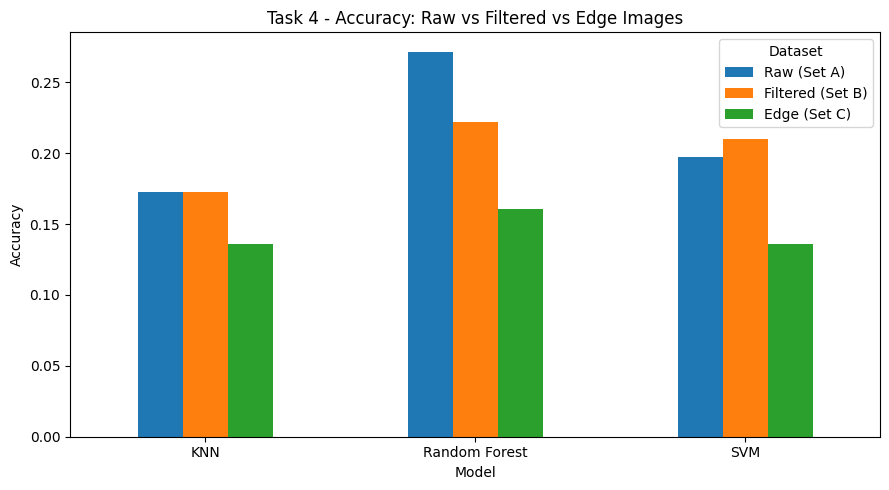

Saved: /content/outputs/task4_accuracy_comparison.png

NOTE: 'trained_models' and 'y_test' / 'idx_test' are kept in memory - Task 5 will reuse them directly for confusion matrices, so keep this runtime alive before moving to Task 5.


In [6]:
import os, cv2, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# =====================================================================
# Lab 03 - Task 4: Classification Using Edge Maps
# Self-contained Colab cell.
#
# ASSUMPTION (please adjust if it doesn't match your Lab 02 result):
#   "Best filtering method" for Set B = Gaussian filtering.
#   Change BEST_FILTER below to "median" if that was your Lab 02 result.
#
# "Best edge detection config" for Set C = the winning Canny config
#   from Task 3 (defaults to low=50, high=150, ksize=5 - update the
#   BEST_CANNY_* constants below if Task 3 picked a different one on
#   your run).
# =====================================================================

# ---- 0. Config / assumptions (EDIT THESE if your Task 3 best differs) ----
BEST_FILTER = "gaussian"          # "gaussian" or "median" - from Lab 02
BEST_CANNY_LOW = 50
BEST_CANNY_HIGH = 150
BEST_CANNY_KSIZE = 5

IMG_SIZE = (64, 64)                # smaller size keeps classical ML fast
SAMPLES_PER_CLASS = 60             # cap per class so this runs in a few minutes
                                    # (raise this later for a fuller run)
RANDOM_STATE = 42

# ---- 1. Dataset (re-download in case runtime was reset) ----
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
base = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
DATASET_DIR = os.path.join(base, "Train")
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

classes = sorted(d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d)))
print("Classes:", classes)

# ---- 2. Load raw images + labels (capped per class for speed) ----
def load_dataset(dataset_dir, classes, samples_per_class, img_size):
    images, labels = [], []
    for label_idx, cls in enumerate(classes):
        cls_dir = os.path.join(dataset_dir, cls)
        files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
        files = files[:samples_per_class]
        for f in files:
            img = cv2.imread(os.path.join(cls_dir, f))
            if img is None:
                continue
            img = cv2.resize(img, img_size)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(gray)
            labels.append(label_idx)
    return np.array(images), np.array(labels)

print("Loading images...")
raw_images, labels = load_dataset(DATASET_DIR, classes, SAMPLES_PER_CLASS, IMG_SIZE)
print(f"Loaded {len(raw_images)} images across {len(classes)} classes.")

# ---- 3. Build Set A (raw), Set B (filtered), Set C (edge) ----
def build_filtered(images, method="gaussian"):
    out = []
    for g in images:
        if method == "gaussian":
            out.append(cv2.GaussianBlur(g, (5, 5), 0))
        else:  # median
            out.append(cv2.medianBlur(g, 5))
    return np.array(out)

def build_edges(images, low, high, ksize):
    out = []
    for g in images:
        g_eq = cv2.equalizeHist(g)
        blurred = cv2.GaussianBlur(g_eq, (ksize, ksize), 0)
        edges = cv2.Canny(blurred, low, high)
        out.append(edges)
    return np.array(out)

print("Building Set A (raw)...")
set_A = raw_images
print("Building Set B (filtered)...")
set_B = build_filtered(raw_images, method=BEST_FILTER)
print("Building Set C (edge)...")
set_C = build_edges(raw_images, BEST_CANNY_LOW, BEST_CANNY_HIGH, BEST_CANNY_KSIZE)

# flatten each image to a feature vector
def flatten(images):
    return images.reshape(images.shape[0], -1).astype(np.float32)

X_A, X_B, X_C = flatten(set_A), flatten(set_B), flatten(set_C)
y = labels

# ---- 4. SAME train/val/test split (indices) for all three sets ----
idx = np.arange(len(y))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=RANDOM_STATE)

print(f"\nSplit sizes -> train: {len(idx_train)}, val: {len(idx_val)}, test: {len(idx_test)}")

def split_set(X):
    return X[idx_train], X[idx_val], X[idx_test]

datasets = {
    "Raw (Set A)": split_set(X_A),
    "Filtered (Set B)": split_set(X_B),
    "Edge (Set C)": split_set(X_C),
}
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

# ---- 5. Classifiers (same models/settings across all 3 datasets) ----
def make_classifiers():
    return {
        "SVM": SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        "KNN": KNeighborsClassifier(n_neighbors=5),
    }

# ---- 6. Train + evaluate each classifier on each dataset variant ----
results = []
trained_models = {}   # keep for Task 5 (confusion matrices etc.)

for set_name, (Xtr, Xval, Xte) in datasets.items():
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    for clf_name, clf in make_classifiers().items():
        t0 = time.time()
        clf.fit(Xtr_s, y_train)
        train_time = time.time() - t0

        t0 = time.time()
        y_pred = clf.predict(Xte_s)
        infer_time_ms = (time.time() - t0) * 1000 / len(Xte_s)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

        results.append({
            "Dataset": set_name,
            "Model": clf_name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-Score": round(f1, 4),
            "Training Time (s)": round(train_time, 2),
            "Inference Time (ms/img)": round(infer_time_ms, 3),
        })
        trained_models[(set_name, clf_name)] = (clf, scaler, y_pred)
        print(f"[{set_name:16s} | {clf_name:14s}] "
              f"acc={acc:.3f} f1={f1:.3f} train={train_time:.1f}s")

results_df = pd.DataFrame(results)
print("\n=== Task 4 Results: Raw vs Filtered vs Edge (SVM / RF / KNN) ===")
print(results_df.to_string(index=False))

out_csv = os.path.join(OUTPUT_DIR, "task4_classification_results.csv")
results_df.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")

# ---- 7. Quick bar chart: accuracy per dataset per model ----
pivot = results_df.pivot(index="Model", columns="Dataset", values="Accuracy")
pivot = pivot[["Raw (Set A)", "Filtered (Set B)", "Edge (Set C)"]]
ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Accuracy")
ax.set_title("Task 4 - Accuracy: Raw vs Filtered vs Edge Images")
plt.xticks(rotation=0)
plt.tight_layout()
out_fig = os.path.join(OUTPUT_DIR, "task4_accuracy_comparison.png")
plt.savefig(out_fig, dpi=150)
plt.show()
print(f"Saved: {out_fig}")

print("\nNOTE: 'trained_models' and 'y_test' / 'idx_test' are kept in memory - "
      "Task 5 will reuse them directly for confusion matrices, so keep this "
      "runtime alive before moving to Task 5.")

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Loading images...
Loaded 540 images across 9 classes.
Split -> train: 378, val: 81, test: 81
[SVM            | Raw (Set A)     ] acc=0.198
[Random Forest  | Raw (Set A)     ] acc=0.272
[KNN            | Raw (Set A)     ] acc=0.173
[SVM            | Filtered (Set B)] acc=0.210
[Random Forest  | Filtered (Set B)] acc=0.222
[KNN            | Filtered (Set B)] acc=0.173
[SVM            | Edge (Set C)    ] acc=0.136
[Random Forest  | Edge (Set C)    ] acc=0.160
[KNN            | Edge (Set C)    ] acc=0.136
[CNN Model 1    | Raw (Set A)     ] acc=0.160 (trained 10 epochs in 16.3s)
[CNN Model 2    | Raw (Set A)     ] acc=0.123 (trained 10 epochs in 57.2s)


[CNN Model 1    | Filtered (Set B)] acc=0.173 (trained 10 epochs in 16.5s)
[CNN Model 2    | Filtered (Set B)] acc=0.111 (trained 10 epochs in 64.0s)
[CNN Model 1    | Edge (Set C)    ] acc=0.148 (trained 10 epochs in 17.4s)
[CNN Model 2    | Edge (Set C)    ] acc=0.111 (trained 10 epochs in 62.1s)

=== Table 3: Cross-Lab Classification Performance Comparison ===
               Accuracy Raw (Lab 1)  Accuracy Filtered (Lab 2)  Accuracy Edge (Lab 3)  Precision  Recall  F1-Score  Training Time (s)  Inference Time (ms)
Model                                                                                                                                                     
SVM                          0.1975                     0.2099                 0.1358     0.0981  0.1358    0.1056             0.4166               1.7488
Random Forest                0.2716                     0.2222                 0.1605     0.1279  0.1605    0.1345             1.2375               0.8304
KNN           

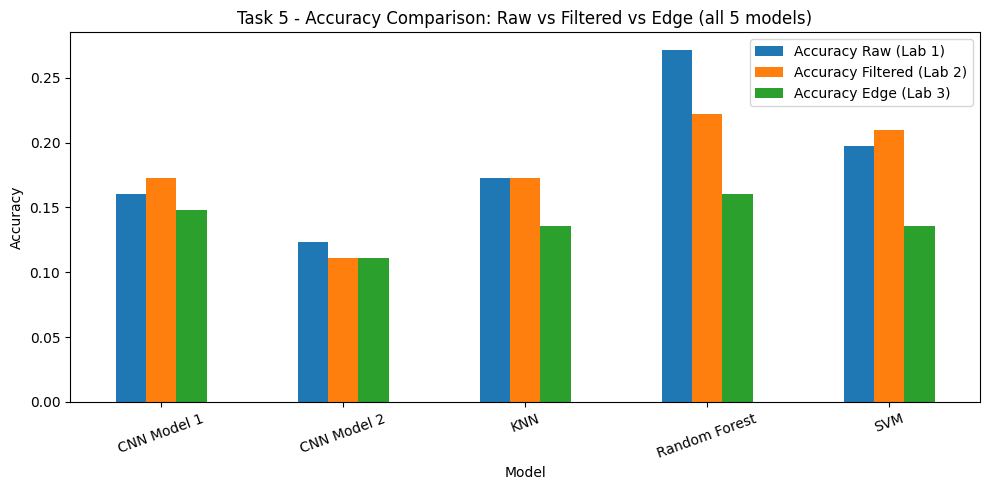

Saved: /content/outputs/task5_accuracy_all_models.png

Best model overall (by Edge accuracy): Random Forest


In [7]:
import os, cv2, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# =====================================================================
# Lab 03 - Task 5: Classification Performance Comparison (Table 3)
# Self-contained: re-downloads dataset, rebuilds Set A/B/C, retrains
# SVM / Random Forest / KNN, and additionally trains 2 CNN models,
# then assembles the final Table 3.
#
# ASSUMPTIONS (edit if they don't match your earlier labs/tasks):
#   - "Best filter" for Set B = Gaussian filtering (from Task 4 default)
#   - "Best Canny config" for Set C = low=50, high=150, kernel=5x5 (Task 3 default)
#   - Table 3's single Precision/Recall/F1/Training/Inference columns
#     are reported using each model's performance on the EDGE dataset
#     (Set C), since that's this lab's focus - Accuracy Raw/Filtered/Edge
#     columns still show all three for comparison.
# =====================================================================

# ---- 0. Config ----
BEST_FILTER = "gaussian"
BEST_CANNY_LOW, BEST_CANNY_HIGH, BEST_CANNY_KSIZE = 50, 150, 5

IMG_SIZE = (64, 64)
SAMPLES_PER_CLASS = 60
RANDOM_STATE = 42
CNN_EPOCHS = 10
CNN_BATCH_SIZE = 32

# ---- 1. Dataset ----
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
base = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
DATASET_DIR = os.path.join(base, "Train")
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

classes = sorted(d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d)))
num_classes = len(classes)
print("Classes:", classes)

def load_dataset(dataset_dir, classes, samples_per_class, img_size):
    images, labels = [], []
    for label_idx, cls in enumerate(classes):
        cls_dir = os.path.join(dataset_dir, cls)
        files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))][:samples_per_class]
        for f in files:
            img = cv2.imread(os.path.join(cls_dir, f))
            if img is None:
                continue
            img = cv2.resize(img, img_size)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(gray)
            labels.append(label_idx)
    return np.array(images), np.array(labels)

print("Loading images...")
raw_images, labels = load_dataset(DATASET_DIR, classes, SAMPLES_PER_CLASS, IMG_SIZE)
print(f"Loaded {len(raw_images)} images across {num_classes} classes.")

# ---- 2. Build Set A / B / C ----
def build_filtered(images, method="gaussian"):
    return np.array([cv2.GaussianBlur(g, (5, 5), 0) if method == "gaussian"
                      else cv2.medianBlur(g, 5) for g in images])

def build_edges(images, low, high, ksize):
    out = []
    for g in images:
        g_eq = cv2.equalizeHist(g)
        blurred = cv2.GaussianBlur(g_eq, (ksize, ksize), 0)
        out.append(cv2.Canny(blurred, low, high))
    return np.array(out)

set_A = raw_images
set_B = build_filtered(raw_images, BEST_FILTER)
set_C = build_edges(raw_images, BEST_CANNY_LOW, BEST_CANNY_HIGH, BEST_CANNY_KSIZE)
y = labels

# ---- 3. Same split (indices) for everything ----
idx = np.arange(len(y))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=RANDOM_STATE)
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
print(f"Split -> train: {len(idx_train)}, val: {len(idx_val)}, test: {len(idx_test)}")

image_sets = {"Raw (Set A)": set_A, "Filtered (Set B)": set_B, "Edge (Set C)": set_C}

# ---- 4. Classical ML (SVM, RF, KNN) on flattened features ----
def flatten(images):
    return images.reshape(images.shape[0], -1).astype(np.float32)

def make_classifiers():
    return {
        "SVM": SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        "KNN": KNeighborsClassifier(n_neighbors=5),
    }

results = []

for set_name, imgs in image_sets.items():
    X = flatten(imgs)
    Xtr, Xte = X[idx_train], X[idx_test]
    scaler = StandardScaler()
    Xtr_s, Xte_s = scaler.fit_transform(Xtr), scaler.transform(Xte)

    for clf_name, clf in make_classifiers().items():
        t0 = time.time(); clf.fit(Xtr_s, y_train); train_time = time.time() - t0
        t0 = time.time(); y_pred = clf.predict(Xte_s)
        infer_ms = (time.time() - t0) * 1000 / len(Xte_s)

        results.append({
            "Model": clf_name, "Dataset": set_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Training Time (s)": train_time,
            "Inference Time (ms)": infer_ms,
        })
        print(f"[{clf_name:14s} | {set_name:16s}] acc={results[-1]['Accuracy']:.3f}")

# ---- 5. CNN Model 1 (shallow) and CNN Model 2 (deeper, with dropout) ----
def build_cnn1(input_shape, n_classes):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_cnn2(input_shape, n_classes):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

cnn_builders = {"CNN Model 1": build_cnn1, "CNN Model 2": build_cnn2}
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 1)

for set_name, imgs in image_sets.items():
    X = imgs.astype(np.float32) / 255.0
    X = X[..., np.newaxis]
    Xtr, Xval, Xte = X[idx_train], X[idx_val], X[idx_test]
    ytr_cat = to_categorical(y_train, num_classes)
    yval_cat = to_categorical(y_val, num_classes)

    for cnn_name, builder in cnn_builders.items():
        tf.random.set_seed(RANDOM_STATE)
        model = builder(input_shape, num_classes)

        t0 = time.time()
        model.fit(Xtr, ytr_cat, validation_data=(Xval, yval_cat),
                  epochs=CNN_EPOCHS, batch_size=CNN_BATCH_SIZE, verbose=0)
        train_time = time.time() - t0

        t0 = time.time()
        y_prob = model.predict(Xte, verbose=0)
        infer_ms = (time.time() - t0) * 1000 / len(Xte)
        y_pred = np.argmax(y_prob, axis=1)

        results.append({
            "Model": cnn_name, "Dataset": set_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Training Time (s)": train_time,
            "Inference Time (ms)": infer_ms,
        })
        print(f"[{cnn_name:14s} | {set_name:16s}] acc={results[-1]['Accuracy']:.3f} "
              f"(trained {CNN_EPOCHS} epochs in {train_time:.1f}s)")

full_results = pd.DataFrame(results)
full_results.to_csv(os.path.join(OUTPUT_DIR, "task5_full_results_long.csv"), index=False)

# ---- 6. Assemble Table 3 (Cross-Lab Classification Performance Comparison) ----
acc_pivot = full_results.pivot(index="Model", columns="Dataset", values="Accuracy")
acc_pivot = acc_pivot[["Raw (Set A)", "Filtered (Set B)", "Edge (Set C)"]]
acc_pivot.columns = ["Accuracy Raw (Lab 1)", "Accuracy Filtered (Lab 2)", "Accuracy Edge (Lab 3)"]

# Precision/Recall/F1/Times reported from the Edge (Set C) results, per this lab's focus
edge_metrics = full_results[full_results["Dataset"] == "Edge (Set C)"].set_index("Model")
edge_metrics = edge_metrics[["Precision", "Recall", "F1-Score", "Training Time (s)", "Inference Time (ms)"]]

table3 = acc_pivot.join(edge_metrics)
model_order = ["SVM", "Random Forest", "KNN", "CNN Model 1", "CNN Model 2"]
table3 = table3.reindex(model_order)
table3 = table3.round(4)

print("\n=== Table 3: Cross-Lab Classification Performance Comparison ===")
print(table3.to_string())
out_csv = os.path.join(OUTPUT_DIR, "table3_cross_lab_comparison.csv")
table3.to_csv(out_csv)
print(f"\nSaved: {out_csv}")

# ---- 7. Bar chart: accuracy across the three representations, per model ----
ax = acc_pivot.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Accuracy")
ax.set_title("Task 5 - Accuracy Comparison: Raw vs Filtered vs Edge (all 5 models)")
plt.xticks(rotation=20)
plt.tight_layout()
out_fig = os.path.join(OUTPUT_DIR, "task5_accuracy_all_models.png")
plt.savefig(out_fig, dpi=150)
plt.show()
print(f"Saved: {out_fig}")

# keep these around for Task 6 (confusion matrices need the best model + its predictions)
print("\nBest model overall (by Edge accuracy):",
      acc_pivot["Accuracy Edge (Lab 3)"].idxmax())

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Loading images...
Loaded 540 images across 9 classes.
[Random Forest | Raw (Set A)] accuracy = 0.272
[Random Forest | Filtered (Set B)] accuracy = 0.222
[Random Forest | Edge (Set C)] accuracy = 0.160

=== Random Forest - Metrics across representations ===
                  Accuracy  Precision  Recall  F1-Score
Dataset                                                
Raw (Set A)         0.2716     0.2312  0.2716    0.2347
Filtered (Set B)    0.2222     0.1754  0.2222    0.1897
Edge (Set C)        0.1605     0.1279  0.1605    0.1345


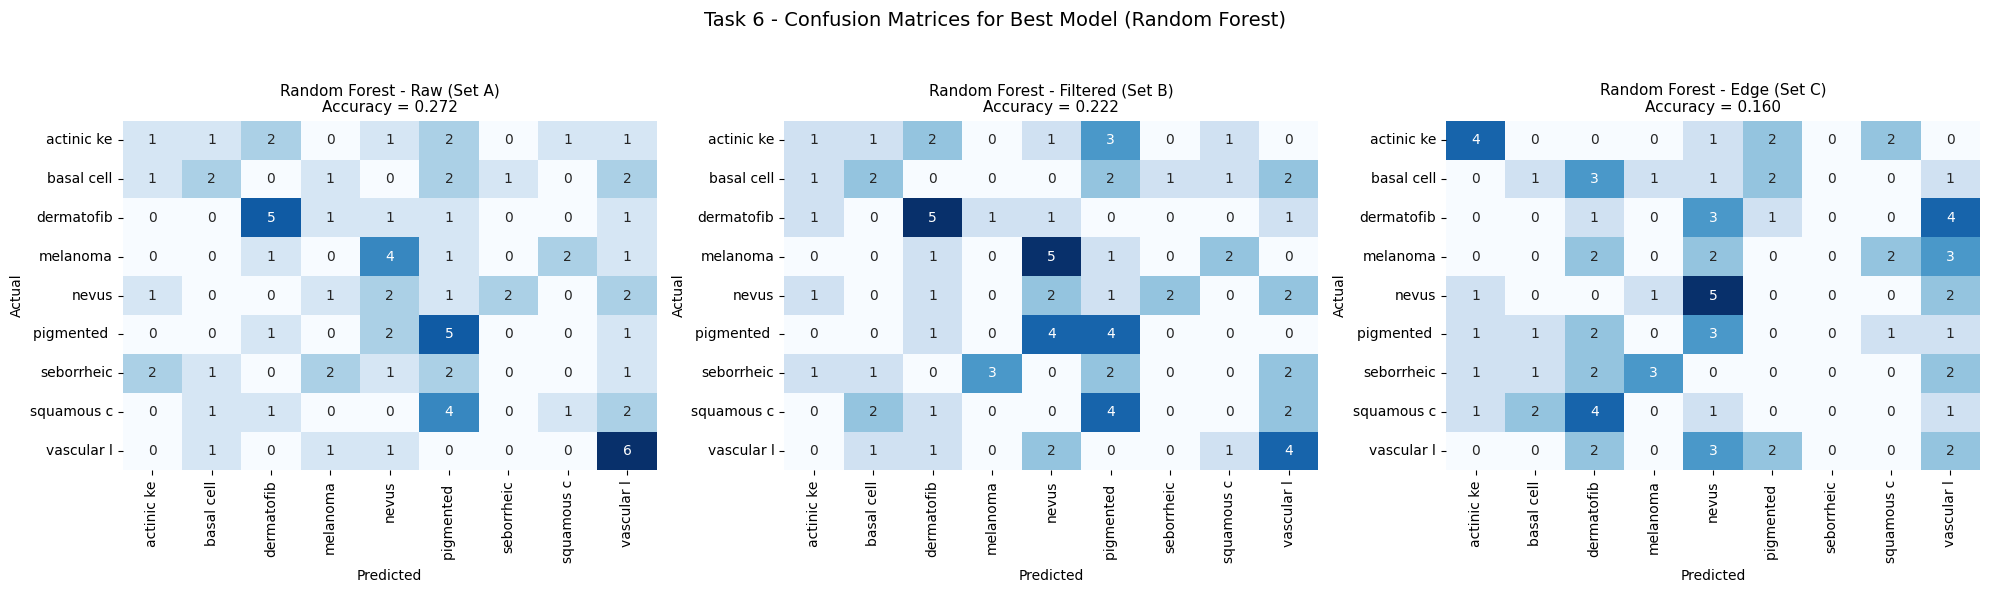

Saved: /content/outputs/task6_confusion_matrices.png


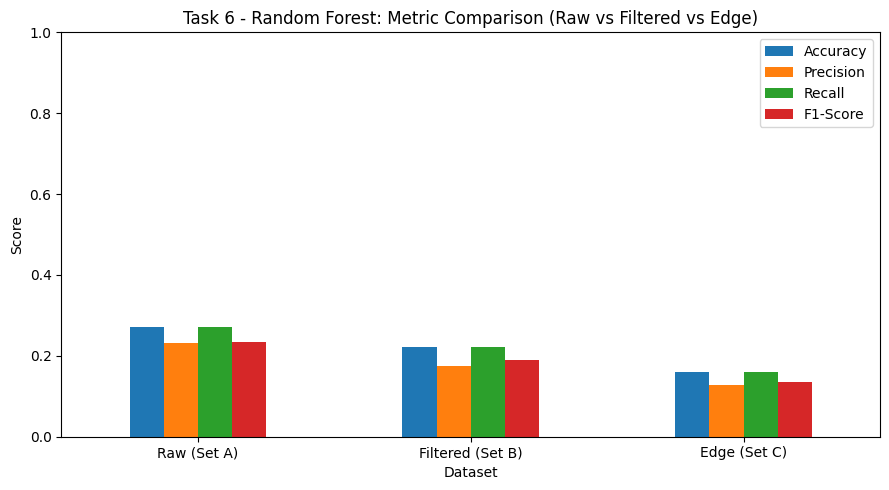

Saved: /content/outputs/task6_metrics_bar_chart.png

=== Discussion: Does edge detection improve or reduce classification performance? ===
Edge-only images REDUCED accuracy (0.160) compared to Raw (0.272) and Filtered (0.222). Edge maps keep only lesion boundary/shape information and discard color, texture and intensity cues - which matter a lot for distinguishing between skin lesion classes in this dataset (e.g. melanoma vs. nevus often differ more in color/texture than in outline shape). This is consistent with Question 5 in the handout: texture, color and intensity information is lost when only edges are kept.


In [8]:
import os, cv2, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler

# =====================================================================
# Lab 03 - Task 6: Visual Comparison of Classification Results
# Self-contained: rebuilds Set A/B/C, trains the BEST model from
# Task 5 (Random Forest), plots confusion matrices for all three
# representations, and a bar chart comparing Accuracy/Precision/
# Recall/F1 across them.
#
# If your Task 5 run picked a different "best model", change
# BEST_MODEL_NAME below (options: "SVM", "Random Forest", "KNN").
# =====================================================================

BEST_MODEL_NAME = "Random Forest"   # <-- from Task 5's printed "Best model overall"

BEST_FILTER = "gaussian"
BEST_CANNY_LOW, BEST_CANNY_HIGH, BEST_CANNY_KSIZE = 50, 150, 5
IMG_SIZE = (64, 64)
SAMPLES_PER_CLASS = 60
RANDOM_STATE = 42

# ---- 1. Dataset ----
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
base = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
DATASET_DIR = os.path.join(base, "Train")
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

classes = sorted(d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d)))
num_classes = len(classes)

def load_dataset(dataset_dir, classes, samples_per_class, img_size):
    images, labels = [], []
    for label_idx, cls in enumerate(classes):
        cls_dir = os.path.join(dataset_dir, cls)
        files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))][:samples_per_class]
        for f in files:
            img = cv2.imread(os.path.join(cls_dir, f))
            if img is None:
                continue
            img = cv2.resize(img, img_size)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(gray)
            labels.append(label_idx)
    return np.array(images), np.array(labels)

print("Loading images...")
raw_images, labels = load_dataset(DATASET_DIR, classes, SAMPLES_PER_CLASS, IMG_SIZE)
print(f"Loaded {len(raw_images)} images across {num_classes} classes.")

# ---- 2. Build Set A / B / C ----
def build_filtered(images, method="gaussian"):
    return np.array([cv2.GaussianBlur(g, (5, 5), 0) if method == "gaussian"
                      else cv2.medianBlur(g, 5) for g in images])

def build_edges(images, low, high, ksize):
    out = []
    for g in images:
        g_eq = cv2.equalizeHist(g)
        blurred = cv2.GaussianBlur(g_eq, (ksize, ksize), 0)
        out.append(cv2.Canny(blurred, low, high))
    return np.array(out)

set_A = raw_images
set_B = build_filtered(raw_images, BEST_FILTER)
set_C = build_edges(raw_images, BEST_CANNY_LOW, BEST_CANNY_HIGH, BEST_CANNY_KSIZE)
y = labels

image_sets = {"Raw (Set A)": set_A, "Filtered (Set B)": set_B, "Edge (Set C)": set_C}

# ---- 3. Same split for everything ----
idx = np.arange(len(y))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=RANDOM_STATE)
y_train, y_test = y[idx_train], y[idx_test]

def flatten(images):
    return images.reshape(images.shape[0], -1).astype(np.float32)

def make_best_model():
    # only Random Forest / SVM / KNN supported here (classical models from Task 4/5)
    if BEST_MODEL_NAME == "Random Forest":
        return RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    elif BEST_MODEL_NAME == "SVM":
        from sklearn.svm import SVC
        return SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE)
    elif BEST_MODEL_NAME == "KNN":
        from sklearn.neighbors import KNeighborsClassifier
        return KNeighborsClassifier(n_neighbors=5)
    else:
        raise ValueError("Unsupported BEST_MODEL_NAME for this script.")

# ---- 4. Train best model on each dataset, collect predictions + metrics ----
predictions = {}
metrics_rows = []

for set_name, imgs in image_sets.items():
    X = flatten(imgs)
    Xtr, Xte = X[idx_train], X[idx_test]
    scaler = StandardScaler()
    Xtr_s, Xte_s = scaler.fit_transform(Xtr), scaler.transform(Xte)

    clf = make_best_model()
    clf.fit(Xtr_s, y_train)
    y_pred = clf.predict(Xte_s)
    predictions[set_name] = y_pred

    metrics_rows.append({
        "Dataset": set_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="macro", zero_division=0),
    })
    print(f"[{BEST_MODEL_NAME} | {set_name}] accuracy = {metrics_rows[-1]['Accuracy']:.3f}")

metrics_df = pd.DataFrame(metrics_rows).set_index("Dataset")
metrics_df = metrics_df.loc[["Raw (Set A)", "Filtered (Set B)", "Edge (Set C)"]]
print(f"\n=== {BEST_MODEL_NAME} - Metrics across representations ===")
print(metrics_df.round(4).to_string())
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "task6_best_model_metrics.csv"))

# ---- 5. Confusion matrices (one per dataset) ----
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
short_labels = [c[:10] for c in classes]  # shorten for readability

for ax, (set_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=short_labels, yticklabels=short_labels, cbar=False)
    ax.set_title(f"{BEST_MODEL_NAME} - {set_name}\nAccuracy = {metrics_df.loc[set_name, 'Accuracy']:.3f}",
                 fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(f"Task 6 - Confusion Matrices for Best Model ({BEST_MODEL_NAME})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
out_cm = os.path.join(OUTPUT_DIR, "task6_confusion_matrices.png")
plt.savefig(out_cm, dpi=150)
plt.show()
print(f"Saved: {out_cm}")

# ---- 6. Bar chart: Accuracy / Precision / Recall / F1 across representations ----
ax = metrics_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Score")
ax.set_title(f"Task 6 - {BEST_MODEL_NAME}: Metric Comparison (Raw vs Filtered vs Edge)")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
out_bar = os.path.join(OUTPUT_DIR, "task6_metrics_bar_chart.png")
plt.savefig(out_bar, dpi=150)
plt.show()
print(f"Saved: {out_bar}")

# ---- 7. Auto discussion summary (edit/expand this in your report) ----
raw_acc = metrics_df.loc["Raw (Set A)", "Accuracy"]
filt_acc = metrics_df.loc["Filtered (Set B)", "Accuracy"]
edge_acc = metrics_df.loc["Edge (Set C)", "Accuracy"]

print("\n=== Discussion: Does edge detection improve or reduce classification performance? ===")
if edge_acc < raw_acc and edge_acc < filt_acc:
    print(f"Edge-only images REDUCED accuracy ({edge_acc:.3f}) compared to Raw ({raw_acc:.3f}) "
          f"and Filtered ({filt_acc:.3f}). Edge maps keep only lesion boundary/shape information "
          "and discard color, texture and intensity cues - which matter a lot for distinguishing "
          "between skin lesion classes in this dataset (e.g. melanoma vs. nevus often differ more "
          "in color/texture than in outline shape). This is consistent with Question 5 in the "
          "handout: texture, color and intensity information is lost when only edges are kept.")
elif edge_acc > raw_acc and edge_acc > filt_acc:
    print(f"Edge-only images IMPROVED accuracy ({edge_acc:.3f}) over Raw ({raw_acc:.3f}) "
          f"and Filtered ({filt_acc:.3f}). This suggests the model benefited from a simplified, "
          "noise-reduced boundary representation for this dataset/classifier combination.")
else:
    print(f"Results were mixed: Raw={raw_acc:.3f}, Filtered={filt_acc:.3f}, Edge={edge_acc:.3f}. "
          "No single representation dominated across all metrics - discuss the trade-offs in your report.")